# 1. Necessary Imports

In [1]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.style.use('ggplot')

start_date = "2019-01-01"
end_date = "2024-01-01"

#functions
from src.portfolio_stats import calculate_volatility, calculate_max_drawdown, calculate_mean_portfolio_returns, calculate_sharpe_ratio, calculate_cagr, calculate_return_path
from src.optimizations import calculate_negative_sharpe_ratio

#data
data = pd.read_csv("data/prices.csv", index_col="Date", parse_dates=True)

from data_loader import read_rfr
rfr = read_rfr(start_date, end_date)


#checking data
print(rfr)
print(data.head())

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

0.022721041324881567
                 AAPL        BND        EEM         GLD        JPM  \
Date                                                                 
2019-01-02  37.503716  64.321205  33.319088  121.330002  81.250198   
2019-01-03  33.768066  64.572411  32.715000  122.430000  80.095497   
2019-01-04  35.209621  64.377922  33.770042  121.440002  83.048264   
2019-01-07  35.131241  64.280685  33.846615  121.860001  83.105980   
2019-01-08  35.800953  64.199654  33.974239  121.529999  82.949280   

                   SPY        TSM        XOM  
Date                                          
2019-01-02  224.995285  31.237259  50.001850  
2019-01-03  219.626282  29.389702  49.234119  
2019-01-04  226.982864  29.911461  51.049381  
2019-01-07  228.772537  30.133856  51.314846  
2019-01-08  230.921906  29.885799  51.687935  


# 2. Optimization

## 2.1. Preparing inputs

In [2]:
equal_weights = np.array([1 / data.columns.size] * data.columns.size)
equal_weights

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [3]:
#negative sharpe
calculate_negative_sharpe_ratio(equal_weights, data)

np.float64(-0.8405056863113298)

In [4]:
#defining bounds and constraints for scipy
constraints = ({
    'type':'eq',
    'fun':lambda weights: np.sum(weights) - 1
    })

n = data.columns.size
bounds = [(0,1)] * n

In [5]:
#define an initial guess for our variable
init_guess = equal_weights
init_guess

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

## 2.2. Global Minimum Variance Portfolio (GMVP)

In [6]:
minimum_variance_portfolio = minimize(calculate_volatility, init_guess, args=(data,), method='SLSQP', bounds=bounds, constraints=constraints)

In [7]:
minimum_variance_portfolio.x

array([0.00000000e+00, 9.19117541e-01, 1.14709232e-18, 3.21247255e-02,
       1.48463504e-02, 0.00000000e+00, 9.00338622e-19, 3.39113829e-02])

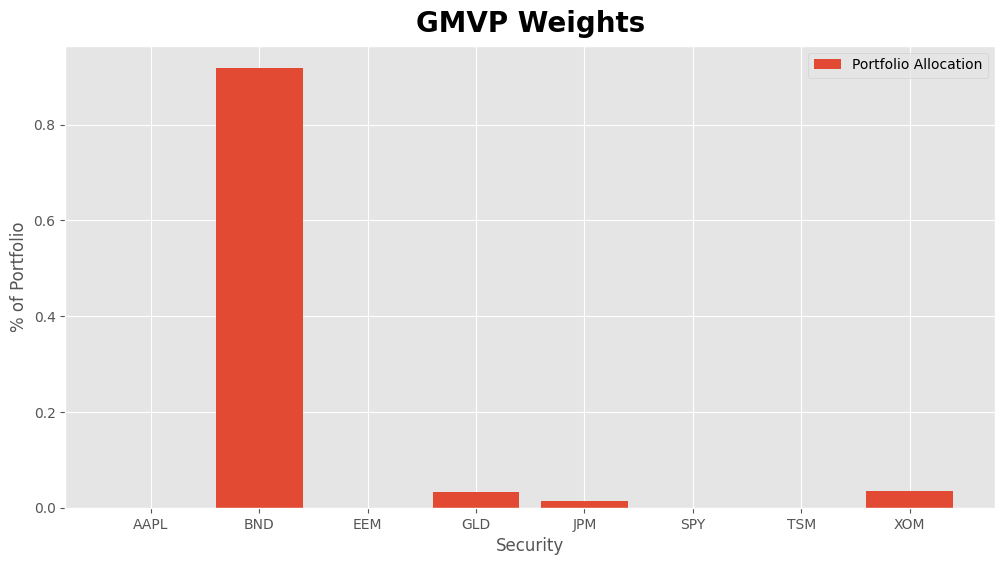

In [8]:
#plotting GMVP
plt.figure(figsize=(12,6))
plt.bar(data.columns, minimum_variance_portfolio.x, label='Portfolio Allocation')
plt.title('GMVP Weights', fontsize=20, pad=10, fontweight='semibold')
plt.xlabel('Security')
plt.ylabel('% of Portfolio')
plt.legend()

In [9]:
#the optimizer is saying that for the minimum global variance we should throw over 90% of the portfolio into bonds.
#what this serves as is a sort of benchmark - it's the leftmost point on the graph, and gives the minimum return we expect.

#let's check what the volatility is:
min_var_port_volatility = calculate_volatility(minimum_variance_portfolio.x, data)

#and what the retuns is (both average and CAGR):
min_var_port_mean_return = calculate_mean_portfolio_returns(minimum_variance_portfolio.x, data)
min_var_port_cagr = calculate_cagr(minimum_variance_portfolio.x, data)

#and the sharpe ratio:
min_var_port_sharpe = calculate_sharpe_ratio(minimum_variance_portfolio.x, data)

print('GMVP Volatility:', min_var_port_volatility)
print('GMVP Mean Returns:', min_var_port_mean_return)
print('GMVP CAGR', min_var_port_cagr)
print('GMVP Sharpe Ratio',min_var_port_sharpe)

GMVP Volatility: 0.06554161422331782
GMVP Mean Returns: 0.02407446291117392
GMVP CAGR 0.022142729514733395
GMVP Sharpe Ratio 0.02064980550648146


## 3.3. Tangency Portfolio (Max Sharpe Ratio)

In [10]:
#to maximize the sharpe we need to minimize the negative sharpe.

tangency_portfolio = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data), constraints=constraints, bounds=bounds)
tangency_portfolio.x

array([4.49710865e-01, 7.18613541e-17, 9.00501773e-17, 4.39863401e-01,
       1.19135482e-16, 0.00000000e+00, 6.95109071e-02, 4.09148270e-02])

In [11]:
#calculating statistics

#let's check what the volatility is:
tangency_port_volatility = calculate_volatility(tangency_portfolio.x, data)

#and what the retuns is (both average and CAGR):
tangency_port_mean_return = calculate_mean_portfolio_returns(tangency_portfolio.x, data)
tangency_port_cagr = calculate_cagr(tangency_portfolio.x, data)

#and the sharpe ratio:
tangency_port_sharpe = calculate_sharpe_ratio(tangency_portfolio.x, data)

print('Tangency Portfolio Volatility:', tangency_port_volatility)
print('Tangency Portfolio Mean Returns:', tangency_port_mean_return)
print('Tangency Portfolio CAGR:', tangency_port_cagr)
print('Tangency Portfolio Sharpe Ratio:',tangency_port_sharpe)

Tangency Portfolio Volatility: 0.1839040983249896
Tangency Portfolio Mean Returns: 0.24325243237785812
Tangency Portfolio CAGR: 0.25365486832685624
Tangency Portfolio Sharpe Ratio: 1.199165179360279


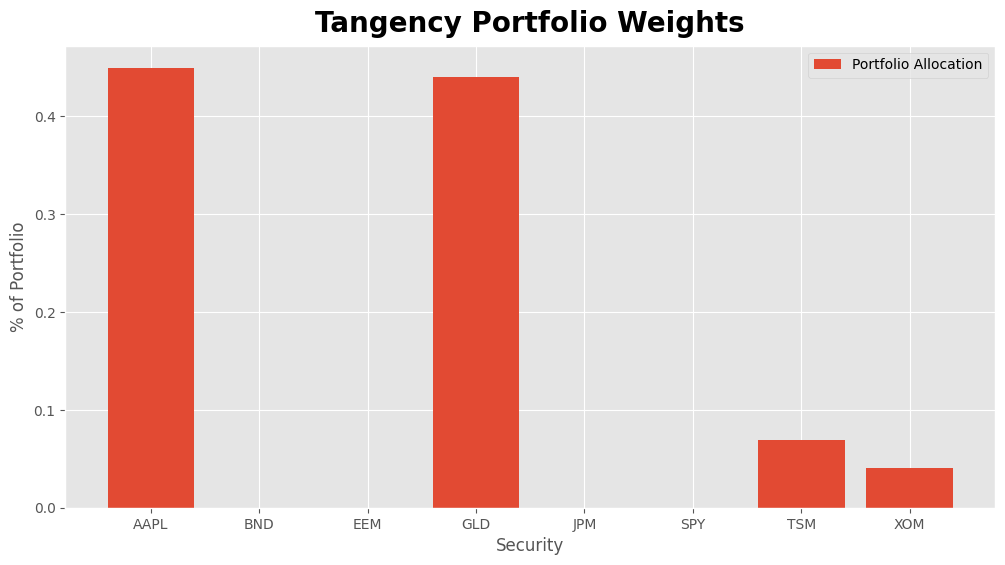

In [12]:
#plotting Tangency Portfolio
plt.figure(figsize=(12,6))
plt.bar(data.columns, tangency_portfolio.x, label='Portfolio Allocation')
plt.title('Tangency Portfolio Weights', fontsize=20, pad=10, fontweight='semibold')
plt.xlabel('Security')
plt.ylabel('% of Portfolio')
plt.legend()

In [13]:
calculate_return_path(equal_weights, data)

array([       nan, 0.97283243, 0.99579441, ..., 2.19539591, 2.19359822,
       2.18738911], shape=(1258,))

## 3.4. Maximum Returns For Given Volatility Levels

In [14]:
#maximizing returns for a given level of volatility - run it across a few: vol_targets = np.linspace(0.08, 0.25, 20)

#reassigning variables to have everything in one place:
n = len(data.columns)
bounds = [(0,1)] * n
init_guess = (np.ones(n)) / 8


In [15]:
from src.optimizations import optimize_portfolios

optimized_port_stats_df, optimized_weights_df = optimize_portfolios(data, 0.06, 0.25, 20)
optimized_port_stats_df

calculating optimal portfolio with 0.06 annualized volatility
calculating optimal portfolio with 0.07 annualized volatility
calculating optimal portfolio with 0.08 annualized volatility
calculating optimal portfolio with 0.09 annualized volatility
calculating optimal portfolio with 0.1 annualized volatility
calculating optimal portfolio with 0.11 annualized volatility
calculating optimal portfolio with 0.12 annualized volatility
calculating optimal portfolio with 0.13 annualized volatility
calculating optimal portfolio with 0.14 annualized volatility
calculating optimal portfolio with 0.15 annualized volatility
calculating optimal portfolio with 0.16 annualized volatility
calculating optimal portfolio with 0.17 annualized volatility
calculating optimal portfolio with 0.18 annualized volatility
calculating optimal portfolio with 0.19 annualized volatility
calculating optimal portfolio with 0.2 annualized volatility
calculating optimal portfolio with 0.21 annualized volatility
calculatin

,Volatility,Max Drawdown,Mean Return,CAGR,Sharpe Ratio
0,0.06,0.151604,0.024137,0.022206,0.021599
1,0.07,0.141040,0.054443,0.053312,0.453175
2,0.08,0.138878,0.082036,0.081938,0.741438
3,0.09,0.138512,0.102542,0.103391,0.886900
4,0.10,0.139653,0.120512,0.122309,0.977908
5,0.11,0.141139,0.137143,0.139912,1.040202
6,0.12,0.147520,0.152949,0.156721,1.085236
7,0.13,0.154637,0.168199,0.173007,1.119060
8,0.14,0.164186,0.183050,0.188930,1.145207
9,0.15,0.173506,0.197605,0.204591,1.165890


In [16]:
optimized_weights_df

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
0,4.647827e-13,9.187703e-01,3.704719e-13,0.032073,1.472776e-02,1.518041e-12,1.602256e-13,0.034429
1,5.205693e-02,7.690114e-01,1.350854e-17,0.113481,1.926243e-02,0.000000e+00,1.045145e-02,0.035737
2,1.033572e-01,6.377680e-01,0.000000e+00,0.183211,2.115299e-02,3.216077e-17,1.795124e-02,0.036559
3,1.414891e-01,5.402316e-01,0.000000e+00,0.235047,2.251548e-02,1.941531e-17,2.352332e-02,0.037193
4,1.749095e-01,4.548843e-01,0.000000e+00,0.280288,2.374909e-02,0.000000e+00,2.845487e-02,0.037714
5,2.058151e-01,3.756850e-01,1.040988e-18,0.322451,2.488385e-02,4.433067e-17,3.295698e-02,0.038208
6,2.348399e-01,3.002000e-01,4.407672e-17,0.362601,2.618920e-02,5.628603e-17,3.754653e-02,0.038623
7,2.634458e-01,2.279240e-01,0.000000e+00,0.400974,2.715427e-02,0.000000e+00,4.153113e-02,0.038970
8,2.911500e-01,1.573193e-01,1.822368e-17,0.438441,2.830516e-02,0.000000e+00,4.540965e-02,0.039375
9,3.180733e-01,8.790543e-02,2.746585e-17,0.475489,2.862961e-02,0.000000e+00,4.954733e-02,0.040356


## 3.5. Plotting Efficient Frontier

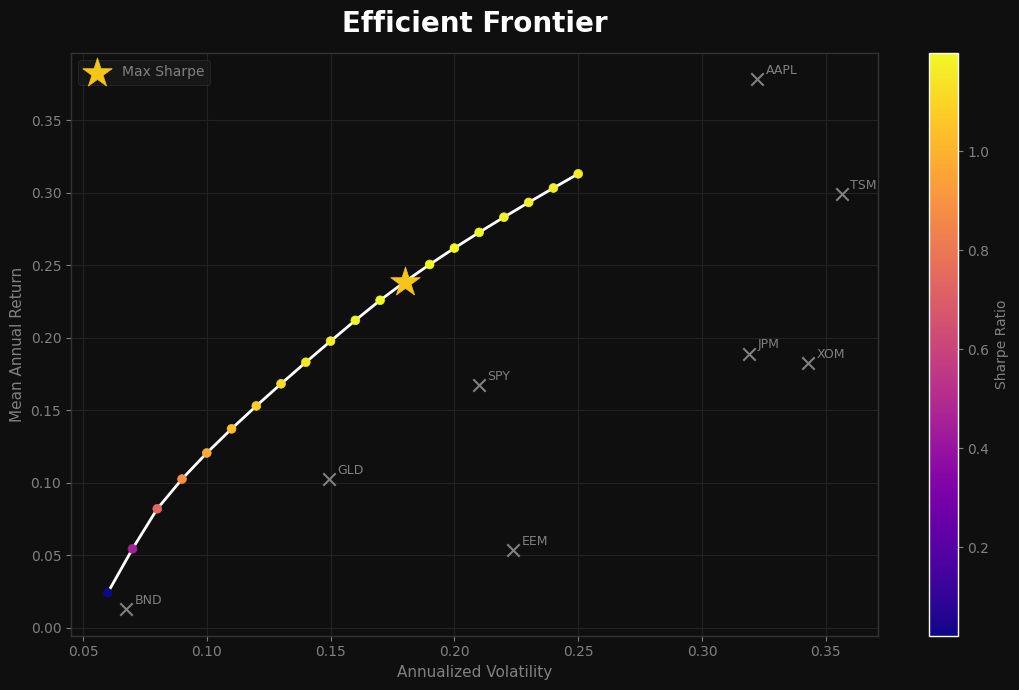

In [17]:
# plotting the efficient frontier
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

# frontier line
ax.plot(optimized_port_stats_df['Volatility'], optimized_port_stats_df['Mean Return'],
        color='white', linewidth=2, zorder=2)

# frontier points colored by sharpe ratio
sc = ax.scatter(optimized_port_stats_df['Volatility'], optimized_port_stats_df['Mean Return'],
                c=optimized_port_stats_df['Sharpe Ratio'], cmap='plasma',
                s=40, zorder=3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Sharpe Ratio', color='grey', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='grey')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='grey')

# individual assets
for col in data.columns:
    single_weight = np.zeros(n)
    single_weight[list(data.columns).index(col)] = 1.0
    asset_vol = calculate_volatility(single_weight, data)
    asset_ret = calculate_mean_portfolio_returns(single_weight, data)
    ax.scatter(asset_vol, asset_ret, marker='x', s=80, color='grey', zorder=4, linewidths=1.5)
    ax.annotate(col, (asset_vol, asset_ret), textcoords="offset points",
                xytext=(6, 4), color='grey', fontsize=9)

# max sharpe portfolio
max_sharpe_idx = optimized_port_stats_df['Sharpe Ratio'].idxmax()
best = optimized_port_stats_df.loc[max_sharpe_idx]
ax.scatter(best['Volatility'], best['Mean Return'],
           color='#f5c518', s=500, zorder=5, marker='*', label='Max Sharpe')

# formatting
ax.set_xlabel('Annualized Volatility', color='grey', fontsize=11)
ax.set_ylabel('Mean Annual Return', color='grey', fontsize=11)
ax.set_title('Efficient Frontier', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

In [18]:
optimized_weights_df

,AAPL,BND,EEM,GLD,JPM,SPY,TSM,XOM
0,4.647827e-13,9.187703e-01,3.704719e-13,0.032073,1.472776e-02,1.518041e-12,1.602256e-13,0.034429
1,5.205693e-02,7.690114e-01,1.350854e-17,0.113481,1.926243e-02,0.000000e+00,1.045145e-02,0.035737
2,1.033572e-01,6.377680e-01,0.000000e+00,0.183211,2.115299e-02,3.216077e-17,1.795124e-02,0.036559
3,1.414891e-01,5.402316e-01,0.000000e+00,0.235047,2.251548e-02,1.941531e-17,2.352332e-02,0.037193
4,1.749095e-01,4.548843e-01,0.000000e+00,0.280288,2.374909e-02,0.000000e+00,2.845487e-02,0.037714
5,2.058151e-01,3.756850e-01,1.040988e-18,0.322451,2.488385e-02,4.433067e-17,3.295698e-02,0.038208
6,2.348399e-01,3.002000e-01,4.407672e-17,0.362601,2.618920e-02,5.628603e-17,3.754653e-02,0.038623
7,2.634458e-01,2.279240e-01,0.000000e+00,0.400974,2.715427e-02,0.000000e+00,4.153113e-02,0.038970
8,2.911500e-01,1.573193e-01,1.822368e-17,0.438441,2.830516e-02,0.000000e+00,4.540965e-02,0.039375
9,3.180733e-01,8.790543e-02,2.746585e-17,0.475489,2.862961e-02,0.000000e+00,4.954733e-02,0.040356


## 3.6. Plotting Optimal Weights For Each Portfolio

/var/folders/4v/1cr4vn8x4yv_p93m1plqw2s80000gn/T/ipykernel_37854/1803478418.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x, rotation=45, ha='right')


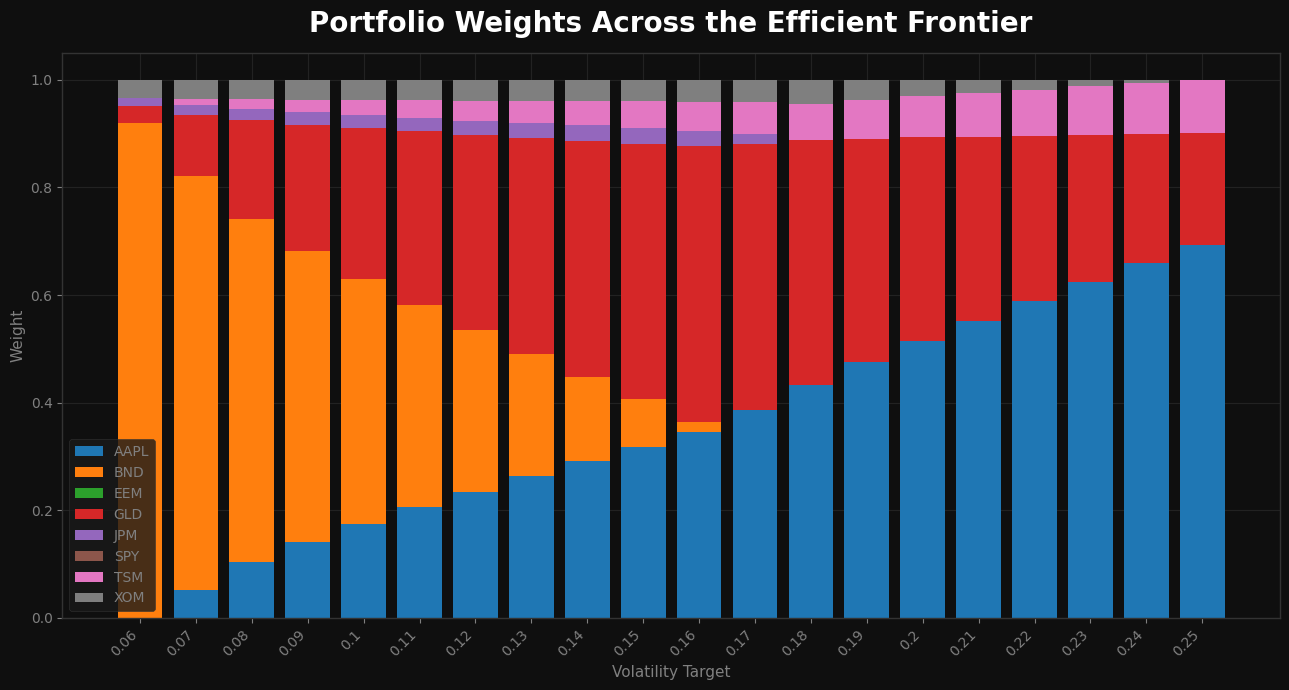

In [19]:
fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

weights_only = optimized_weights_df.drop(columns='Volatility') if 'Volatility' in optimized_weights_df.columns else optimized_weights_df
x = optimized_port_stats_df['Volatility'].round(3).astype(str)
bottom = np.zeros(len(optimized_weights_df))

#colors = plt.cm.plasma(np.linspace(0.1, 0.9, n))
colors = plt.cm.tab10.colors

for i, col in enumerate(weights_only.columns):
    ax.bar(x, weights_only[col], bottom=bottom, label=col, color=colors[i])
    bottom += weights_only[col].values

ax.set_xlabel('Volatility Target', color='grey', fontsize=11)
ax.set_ylabel('Weight', color='grey', fontsize=11)
ax.set_title('Portfolio Weights Across the Efficient Frontier', color='white', fontsize=20, fontweight='bold', pad=15)
ax.tick_params(colors='grey')
ax.set_xticklabels(x, rotation=45, ha='right')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')
ax.grid(True, color='#222222', linewidth=0.8)
ax.legend(facecolor='#1a1a1a', edgecolor='#333333', labelcolor='grey', fontsize=10)

plt.tight_layout()
plt.show()

## 3.7 Sensitivity Test (Overfitting?)

<BarContainer object of 8 artists>

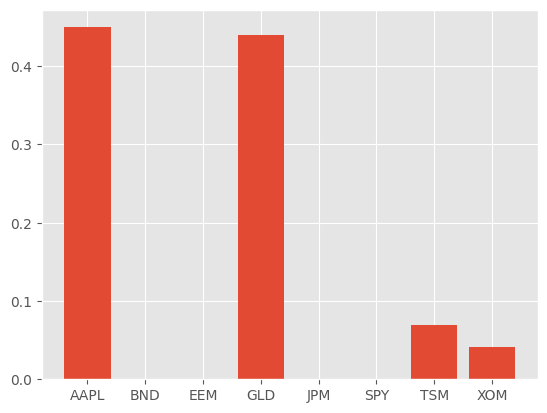

In [20]:
#LASTLY: CHECKING MPTs SENSITIVITY TO THE INPUT - TRYING DIFFERENT TIME-FRAMES AS INPUT

#comparing tangency portfolios:
plt.bar(data.columns, tangency_portfolio.x)


In [21]:
tickers = data.columns.tolist()
tickers

['AAPL', 'BND', 'EEM', 'GLD', 'JPM', 'SPY', 'TSM', 'XOM']

In [22]:
import yfinance as yf

data_6y = yf.download(tickers, start='2018-01-01', end='2024-01-01', auto_adjust=True)['Close']
data_7y = yf.download(tickers, start='2015-01-01', end='2024-01-01', auto_adjust=True)['Close']
data_3y = yf.download(tickers, start='2021-01-01', end='2024-01-01', auto_adjust=True)['Close']

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


In [23]:
tangency_portfolio_6y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_6y), constraints=constraints, bounds=bounds)
tangency_portfolio_7y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_7y), constraints=constraints, bounds=bounds)
tangency_portfolio_3y = minimize(calculate_negative_sharpe_ratio, init_guess, args=(data_3y), constraints=constraints, bounds=bounds)

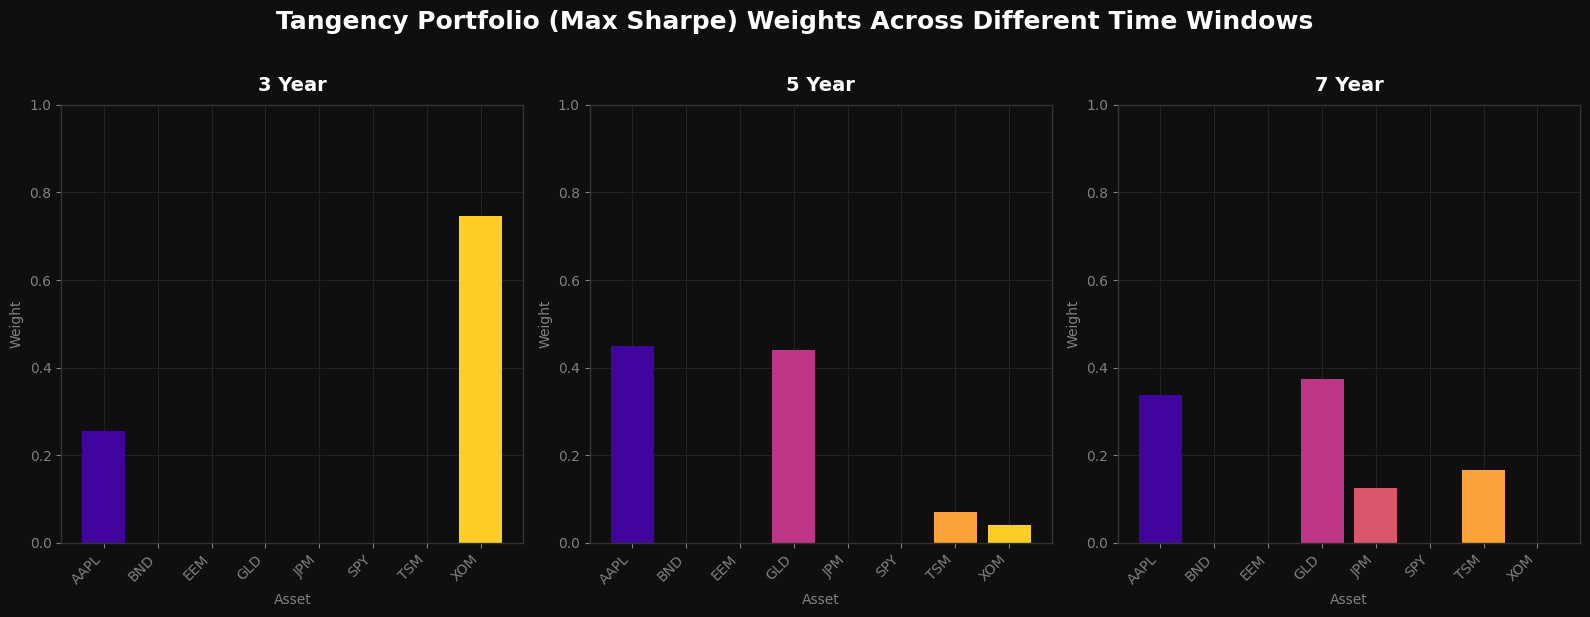

In [24]:
portfolios = {
    '3 Year': tangency_portfolio_3y,
    '5 Year': tangency_portfolio,
    '7 Year': tangency_portfolio_7y,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#0f0f0f')

for ax, (label, portfolio) in zip(axes, portfolios.items()):
    weights = portfolio.x
    ax.bar(data.columns, weights, color=plt.cm.plasma(np.linspace(0.1, 0.9, n)))
    
    # formatting
    ax.set_facecolor('#0f0f0f')
    ax.set_title(label, color='white', fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Asset', color='grey', fontsize=10)
    ax.set_ylabel('Weight', color='grey', fontsize=10)
    ax.tick_params(colors='grey')
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    ax.grid(True, color='#222222', linewidth=0.8)
    ax.set_ylim(0, 1)

fig.suptitle('Tangency Portfolio (Max Sharpe) Weights Across Different Time Windows', 
             color='white', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [25]:
# the graph above shows the huge sensitivity and over-reliance of MVO on the historical data you feed it. 

# Markowitz assumes expected returns are stationary — that the true mean return is a fixed number you're trying to estimate.
# But asset returns aren't stationary. Companies change, industries change, macro regimes change.
# No amount of historical data gives you a reliable estimate of future expected returns because the future distribution
# is genuinely different from the past one.